## **Notebook 01: EDA - Análise Exploratória Dataset (dados_ipdm.csv):**

In [442]:
# *********** AVISO!!!!! ************

# Se for a primeira vez rodando, remova o '#' das linhas abaixo:

# install.packages(
#     c("glue", 
#       "dplyr", 
#       "tidyverse"))

### **Fase 1 EDA (Exploratory Data Analysis) + Limpeza e Estruturação dos Dados**

In [443]:
library(glue)

usuario <- 'Megalonnix'
repositorio <- 'Projeto_Integrador_PI3_2Sem_2026'
nm_dataset_usado <- 'dados_ipdm.csv'

# 1. Cria a URL correta com o "raw." no início e a barra antes do usuário
URL_GITHUB <- glue(
'https://raw.githubusercontent.com/{usuario}/{repositorio}/main/{nm_dataset_usado}')

# 2. Lê o arquivo CSV diretamente da internet
df <- read.csv(URL_GITHUB, sep = ";", dec = ",", fileEncoding = 'Latin1')


In [444]:
# ---------------------------------------------------------
# BLOCO 1: Nomes das colunas e Tipos de Dados
# ---------------------------------------------------------

# Lista apenas os nomes das colunas
cat("--- LISTA DE COLUNAS ---\n")
print(colnames(df))

# Exibe a estrutura completa (Nome da coluna, Tipo de dado e Amostra dos valores)
cat("\n--- ESTRUTURA E TIPOS DE DADOS ---\n")
library(dplyr)
glimpse(df)

--- LISTA DE COLUNAS ---


 [1] "cod_ibge"     "Municipio"    "Valor"        "Ano"          "Tipo"        
 [6] "Valor.Estado" "Indicador.1"  "Indicador.2"  "Indicador.3"  "Indicador.4" 
[11] "Indicador.5"  "X"           

--- ESTRUTURA E TIPOS DE DADOS ---
Rows: 61,920
Columns: 12
$ cod_ibge     <int> 3500105, 3500105, 3500105, 3500105, 3500105, 3500105, 350…
$ Municipio    <chr> "Adamantina", "Adamantina", "Adamantina", "Adamantina", "…
$ Valor        <dbl> 0.365, 0.365, 0.382, 0.378, 0.359, 0.381, 0.386, 0.356, 0…
$ Ano          <int> 2014, 2016, 2018, 2020, 2022, 2024, 2014, 2016, 2018, 202…
$ Tipo         <chr> "Riqueza", "Riqueza", "Riqueza", "Riqueza", "Riqueza", "R…
$ Valor.Estado <dbl> 0.457, 0.438, 0.451, 0.439, 0.441, 0.464, 0.457, 0.438, 0…
$ Indicador.1  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.2  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.3  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.4  <chr> "",

In [445]:
df <- df %>% select(-X)
glimpse(df)

Rows: 61,920
Columns: 11
$ cod_ibge     <int> 3500105, 3500105, 3500105, 3500105, 3500105, 3500105, 350…
$ Municipio    <chr> "Adamantina", "Adamantina", "Adamantina", "Adamantina", "…
$ Valor        <dbl> 0.365, 0.365, 0.382, 0.378, 0.359, 0.381, 0.386, 0.356, 0…
$ Ano          <int> 2014, 2016, 2018, 2020, 2022, 2024, 2014, 2016, 2018, 202…
$ Tipo         <chr> "Riqueza", "Riqueza", "Riqueza", "Riqueza", "Riqueza", "R…
$ Valor.Estado <dbl> 0.457, 0.438, 0.451, 0.439, 0.441, 0.464, 0.457, 0.438, 0…
$ Indicador.1  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.2  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.3  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.4  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.5  <chr> "Indicador Riqueza", "Indicador Riqueza", "Indicador Riqu…


In [446]:
as.list(colnames(df))

[[1]]
[1] "cod_ibge"

[[2]]
[1] "Municipio"

[[3]]
[1] "Valor"

[[4]]
[1] "Ano"

[[5]]
[1] "Tipo"

[[6]]
[1] "Valor.Estado"

[[7]]
[1] "Indicador.1"

[[8]]
[1] "Indicador.2"

[[9]]
[1] "Indicador.3"

[[10]]
[1] "Indicador.4"

[[11]]
[1] "Indicador.5"

In [447]:
colnames(df) <- c(
    "cod_ibge", 
    "municipio", 
    "valor", 
    "ano", 
    "tipo", 
    "valor_estado", 
    "indicador_1", 
    "indicador_2", 
    "indicador_3", 
    "indicador_4", 
    "indicador_5")
    

In [448]:
View(head(df, 3))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,0.365,2014,Riqueza,0.457,,,,,Indicador Riqueza
2,3500105,Adamantina,0.365,2016,Riqueza,0.438,,,,,Indicador Riqueza
3,3500105,Adamantina,0.382,2018,Riqueza,0.451,,,,,Indicador Riqueza


In [449]:
# ======================================
# Me livrando de dados vazios/nulos/etc ...
# ======================================

# 1. Tratamento de vírgulas para ponto
df$valor <- as.numeric(gsub(",", ".", df$valor))
df$valor_estado <- as.numeric(gsub(",", ".", df$valor_estado))

# 2. Filtro da coluna 'valor' (remove NAs e zeros)
df <- df[!is.na(df$valor) & df$valor != 0, ]

# 3. Limpeza manual de texto (municipio e tipo)
df <- df[!is.na(df$municipio) & trimws(df$municipio) != "", ]
df <- df[!is.na(df$tipo) & trimws(df$tipo) != "", ]

In [450]:
View(head(df, 3))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,0.365,2014,Riqueza,0.457,,,,,Indicador Riqueza
2,3500105,Adamantina,0.365,2016,Riqueza,0.438,,,,,Indicador Riqueza
3,3500105,Adamantina,0.382,2018,Riqueza,0.451,,,,,Indicador Riqueza


In [451]:
library(dplyr)

# 1. Filtra as notas padronizadas (0 a 1)
df_notas <- df %>% 
  filter(trimws(indicador_5) != "" | (valor <= 1 & valor_estado <= 1))

# 2. Filtra os dados brutos (reais, taxas, porcentagens, etc.)
df_brutos <- df %>% 
  filter(trimws(indicador_5) == "" & (valor > 1 | valor_estado > 1))

In [452]:
# Passo 0 - Captura o tipo de info. presente
# no Dom(C), no caso, Dom(coluna). 

get_resumo_colunas <- function(df, limite = 20) {

  tabela <- do.call(rbind, lapply(names(df), function(col) 
  {  
    x <- df[[col]]
    
    # Identifica o tipo
    tipo <- class(x)[1]
    if (is.character(x)) tipo <- "string"
    else if (is.logical(x)) tipo <- "boolean"
    else if (is.numeric(x)) tipo <- "numeric"
    
    # Processa o domínio
    vals <- unique(na.omit(x))
    qtd <- length(vals)
    
    if (is.numeric(x) && qtd > limite) {
      dom <- sprintf(
        "(%s, ..., %s)", 
        min(x, na.rm = TRUE), 
        max(x, na.rm = TRUE))
    } else if (qtd <= limite) {
      
      # Remove strings vazias da exibição visual se desejar
      vals_limpos <- vals[vals != ""] 
      dom <- sprintf(
        "(%s)", 
        paste(vals_limpos, collapse = ", "))
    } else {
      dom <- sprintf(
        "(%d valores distintos)", qtd)
    }
    
    data.frame(
      Coluna = col, 
      Tipo = tipo, 
      Dominio = dom, 
      stringsAsFactors = FALSE)
  }))
  
  return(tabela)
}

### **Interpretando medidas de desenvolvimento:**

* **[AVISO]:** Dados extremamente difíceis de ler (**ETL + pesado necessário**) !!!

In [453]:
# Abre uma aba interativa estilo Excel/Matrix no RStudio
View(get_resumo_colunas(df))

Coluna,Tipo,Dominio
<chr>,<chr>,<chr>
cod_ibge,numeric,"(3500105, ..., 3557303)"
municipio,string,(645 valores distintos)
valor,numeric,"(0.140173816, ..., 732026.5279)"
ano,numeric,"(2014, 2016, 2018, 2020, 2022, 2024)"
tipo,string,"(Riqueza, Longevidade, Escolaridade, IPDM)"
valor_estado,numeric,"(0.438, ..., 90454.96)"
indicador_1,string,"(Taxas de mortalidade infantil (por mil nascidos vivos), Taxas de atendimento escolar de crianças de 0 a 3 anos (%), Consumo anual de energia elétrica residencial (MWh) por ligação)"
indicador_2,string,"(Taxas de mortalidade perinatal (por mil nascidos vivos), Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%), Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação)"
indicador_3,string,"(Taxas de mortalidade 15 a 39 anos (por mil hab.), Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024), Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%))"


In [454]:
# Resumo enxuto focando APENAS em valor e valor_estado
get_resumo_valores <- function(df_notas, df_brutos) {
  data.frame(
    Dataframe = c("Notas (0 a 1)", "Notas (0 a 1)", "Dados Brutos", "Dados Brutos"),
    Coluna    = c("valor", "valor_estado", "valor", "valor_estado"),
    Minimo    = c(min(df_notas$valor, na.rm=TRUE), 
                  min(df_notas$valor_estado, na.rm=TRUE), 
                  min(df_brutos$valor, na.rm=TRUE), 
                  min(df_brutos$valor_estado, na.rm=TRUE)),
    Maximo    = c(max(df_notas$valor, na.rm=TRUE), 
                  max(df_notas$valor_estado, na.rm=TRUE), 
                  max(df_brutos$valor, na.rm=TRUE), 
                  max(df_brutos$valor_estado, na.rm=TRUE))
  )
}

# Execução
get_resumo_valores(df_notas, df_brutos)

Dataframe,Coluna,Minimo,Maximo
<chr>,<chr>,<dbl>,<dbl>
Notas (0 a 1),valor,0.1450000,0.988
Notas (0 a 1),valor_estado,0.4380000,0.722
Dados Brutos,valor,0.1401738,732026.528
Dados Brutos,valor_estado,1.1500000,90454.960


In [455]:
View(head(df_notas, 4))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,0.365,2014,Riqueza,0.457,,,,,Indicador Riqueza
2,3500105,Adamantina,0.365,2016,Riqueza,0.438,,,,,Indicador Riqueza
3,3500105,Adamantina,0.382,2018,Riqueza,0.451,,,,,Indicador Riqueza
4,3500105,Adamantina,0.378,2020,Riqueza,0.439,,,,,Indicador Riqueza


In [456]:
View(head(df_brutos, 4))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,12.87996,2014,Longevidade,15.79,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),
2,3500105,Adamantina,12.96720,2016,Longevidade,15.58,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),
3,3500105,Adamantina,12.82766,2018,Longevidade,15.40,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),
4,3500105,Adamantina,12.91236,2020,Longevidade,15.77,,,,Taxas de mortalidade 60 a 69 anos (por mil hab.),


In [457]:
dominios_individuais <- df %>%
  select(tipo, 
  indicador_1, 
  indicador_2, 
  indicador_3, 
  indicador_4, 
  indicador_5) %>% lapply(unique)

# Exibe o resultado no console para você inspecionar
print("=== DOMÍNIO DE CADA COLUNA INDIVIDUAL ===")
print(dominios_individuais)

[1] "=== DOMÍNIO DE CADA COLUNA INDIVIDUAL ==="
$tipo
[1] "Riqueza"      "Longevidade"  "Escolaridade" "IPDM"        

$indicador_1
[1] ""                                                               
[2] "Taxas de mortalidade infantil (por mil nascidos vivos)"         
[3] "Taxas de atendimento escolar de crianças de 0 a 3 anos (%)"     
[4] "Consumo anual de energia elétrica residencial (MWh) por ligação"

$indicador_2
[1] ""                                                                                          
[2] "Taxas de mortalidade perinatal (por mil nascidos vivos)"                                   
[3] "Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)"
[4] "Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação"           

$indicador_3
[1] ""                                                                                           
[2] "Taxas de mortalidade 15 a 39 anos (por mil hab.)"                    

In [458]:
library(dplyr)
library(tidyr)

# 1. Isolar as Notas Sintéticas (IPDM - Indicador 5)
df_ipdm <- df %>%
  filter(indicador_5 != "") %>%
  # Como aqui só importa o indicador 5, podemos remover as outras colunas para limpar o df
  select(-indicador_1, -indicador_2, -indicador_3, -indicador_4) 

# 2. Processar e Isolar as Variáveis Brutas
df_brutos_unificados <- df %>%
  filter(indicador_5 == "") %>%
  # O pivot_longer vai "derreter" as colunas de 1 a 4. 
  # Ele pega o nome do indicador, onde quer que ele esteja, e joga para uma única coluna.
  pivot_longer(
    cols = indicador_1:indicador_4,
    names_to = "coluna_origem",
    values_to = "metrica"
  ) %>%
  # Remove as linhas que ficaram vazias no processo de derretimento
  filter(metrica != "") %>%
  # Remove a coluna_origem e indicador_5, pois não têm mais utilidade
  select(-coluna_origem, -indicador_5)

# 3. Separar cada variável em seu próprio dataframe
# A função split() divide o dataframe em uma lista de dataframes, 
# usando a coluna 'metrica' como regra de corte.
lista_variaveis <- split(df_brutos_unificados, df_brutos_unificados$metrica)

# =========================================================================
# COMO USAR OS DATASETS ISOLADOS:
# Agora você tem uma lista. Para extrair o dataset isolado de uma variável 
# específica para a sua EDA, basta chamar pelo nome exato dela:
# =========================================================================

df_pib <- lista_variaveis[["Produto Interno Bruto per capita (R$ de 2024)"]]
df_renda <- lista_variaveis[["Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024)"]]
df_energia_res <- lista_variaveis[["Consumo anual de energia elétrica residencial (MWh) por ligação"]]
df_mortalidade_infantil <- lista_variaveis[["Taxas de mortalidade infantil (por mil nascidos vivos)"]]
df_x <- lista_variaveis[["Taxas de atendimento escolar de crianças de 0 a 3 anos (%)"]]

#### **Dataset contendo maior parte das métricas brutas e limpas as quais desejo selecionar separadamente:**

In [459]:
View(head(df_brutos_unificados, 3))

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,12.87996,2014,Longevidade,15.79,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.96720,2016,Longevidade,15.58,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.82766,2018,Longevidade,15.40,Taxas de mortalidade 60 a 69 anos (por mil hab.)


In [460]:
valores_unicos <- unique(df_brutos_unificados$metrica)
print(valores_unicos)

 [1] "Taxas de mortalidade  60 a 69 anos (por mil hab.)"                                          
 [2] "Taxas de distorção idade-série no Ensino Médio (%)"                                         
 [3] "Produto Interno Bruto per capita (R$ de 2024)"                                              
 [4] "Taxas de mortalidade 15 a 39 anos (por mil hab.)"                                           
 [5] "Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024)"      
 [6] "Proporção média de  alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)"
 [7] "Taxas de mortalidade perinatal (por mil nascidos vivos)"                                    
 [8] "Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)" 
 [9] "Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação"            
[10] "Taxas de mortalidade infantil (por mil nascidos vivos)"                                     
[11] "Taxa

In [461]:
# =========================================================
# DIMENSÃO: LONGEVIDADE (Saúde e Mortalidade)
# =========================================================
df_mort_infantil <- lista_variaveis[["Taxas de mortalidade infantil (por mil nascidos vivos)"]]
df_mort_perinatal <- lista_variaveis[["Taxas de mortalidade perinatal (por mil nascidos vivos)"]]
df_mort_15_39 <- lista_variaveis[["Taxas de mortalidade 15 a 39 anos (por mil hab.)"]]
df_mort_60_69 <- lista_variaveis[["Taxas de mortalidade  60 a 69 anos (por mil hab.)"]] # Atenção ao espaço duplo original

# =========================================================
# DIMENSÃO: ESCOLARIDADE (Educação)
# =========================================================
df_atendimento_0_3 <- lista_variaveis[["Taxas de atendimento escolar de crianças de 0 a 3 anos (%)"]]
df_prof_5ano <- lista_variaveis[["Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)"]]
df_prof_9ano <- lista_variaveis[["Proporção média de  alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)"]] # Atenção ao espaço duplo
df_distorcao_em <- lista_variaveis[["Taxas de distorção idade-série no Ensino Médio (%)"]]

# =========================================================
# DIMENSÃO: RIQUEZA (Economia e Consumo)
# =========================================================
df_pib <- lista_variaveis[["Produto Interno Bruto per capita (R$ de 2024)"]]
df_renda <- lista_variaveis[["Rendimento do trabalho formal mais benefícios previdenciarios per capita (R$ de 2024)"]]
df_energia_res <- lista_variaveis[["Consumo anual de energia elétrica residencial (MWh) por ligação"]]
df_energia_com <- lista_variaveis[["Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação"]]

### **Separando medidas de desenvolvimento as quais irei usar:**

#### **Medidas de Desenvolvimento Econômico - IPDM**

Abaixo irei separar as 12 medidas de desenvolvimento econômico extraídas do dataset `dados_ipdm.csv`, organizadas por suas respectivas categorias temáticas.

#### **1. Longevidade (Saúde)**
*   **longevidade_1**: Taxas de mortalidade infantil (por mil nascidos vivos)
*   **longevidade_2**: Taxas de mortalidade perinatal (por mil nascidos vivos)
*   **longevidade_3**: Taxas de mortalidade 15 a 39 anos (por mil hab.)
*   **longevidade_4**: Taxas de mortalidade 60 a 69 anos (por mil hab.)

#### **2. Escolaridade (Educação)**
*   **escolaridade_1**: Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
*   **escolaridade_2**: Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
*   **escolaridade_3**: Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
*   **escolaridade_4**: Taxas de distorção idade-série no Ensino Médio (%)

#### **3. Riqueza (Economia e Consumo)**
*   **economia_1**: Produto Interno Bruto per capita (R$ de 2024)
*   **economia_2**: Rendimento do trabalho formal mais benefícios previdenciários per capita (R$ de 2024)
*   **consumo_1**: Consumo anual de energia elétrica residencial (MWh) por ligação
*   **consumo_2**: Consumo anual de energia elétrica comercial, serviços e rural (MWh) por ligação

In [462]:
MEDIDAS_DESENV <- list(
    longevidade_1 = df_mort_infantil, 
    longevidade_2 = df_mort_perinatal,
    longevidade_3 = df_mort_15_39, 
    longevidade_4 = df_mort_60_69, 

    escolaridade_1 = df_atendimento_0_3, 
    escolaridade_2 = df_prof_5ano, 
    escolaridade_3 = df_prof_9ano, 
    escolaridade_4 = df_distorcao_em, 

    economia_1 = df_pib, 
    economia_2 = df_renda, 
    consumo_1 = df_energia_res, 
    consumo_2 = df_energia_com )

### **Principais Indicadores de Desenvolvimento (Separados):**

Indicadores de desenvolvimento estão em 3 categorias:

  -  1) Longevidade
  -  2) Escolaridade
  -  3) Economia e Consumo

Cada uma dessas categorias possui alguns subtópicos, totalizando 12 datasets separados, pois são 12 variáveis diferentes no total.

In [463]:
# Mostra os pedacinhos do dataset novo q eu quero olhar ... :D

showPieceOfData <- function(nm_coluna) {
    View(
    head(MEDIDAS_DESENV[[nm_coluna]], 4))
}

In [464]:
# View(head(MEDIDAS_DESENV$longevidade_1, 4)) # <-- Versão original minha ...

showPieceOfData(nm_coluna = 'longevidade_1')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,7.421150,2014,Longevidade,11.45,Taxas de mortalidade infantil (por mil nascidos vivos)
3500105,Adamantina,12.855831,2016,Longevidade,10.76,Taxas de mortalidade infantil (por mil nascidos vivos)
3500105,Adamantina,10.810811,2018,Longevidade,10.78,Taxas de mortalidade infantil (por mil nascidos vivos)
3500105,Adamantina,3.384095,2020,Longevidade,10.47,Taxas de mortalidade infantil (por mil nascidos vivos)


In [465]:
showPieceOfData(nm_coluna = 'longevidade_2')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,11.05991,2014,Longevidade,13.43,Taxas de mortalidade perinatal (por mil nascidos vivos)
3500105,Adamantina,14.54545,2016,Longevidade,12.46,Taxas de mortalidade perinatal (por mil nascidos vivos)
3500105,Adamantina,19.53819,2018,Longevidade,12.31,Taxas de mortalidade perinatal (por mil nascidos vivos)
3500105,Adamantina,12.57334,2020,Longevidade,11.96,Taxas de mortalidade perinatal (por mil nascidos vivos)


In [466]:
showPieceOfData(nm_coluna = 'longevidade_3')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,1.013820,2014,Longevidade,1.32,Taxas de mortalidade 15 a 39 anos (por mil hab.)
3500105,Adamantina,1.062092,2016,Longevidade,1.19,Taxas de mortalidade 15 a 39 anos (por mil hab.)
3500105,Adamantina,1.044760,2018,Longevidade,1.15,Taxas de mortalidade 15 a 39 anos (por mil hab.)
3500105,Adamantina,1.065142,2020,Longevidade,1.17,Taxas de mortalidade 15 a 39 anos (por mil hab.)


In [467]:
showPieceOfData(nm_coluna = 'longevidade_4')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,12.87996,2014,Longevidade,15.79,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.96720,2016,Longevidade,15.58,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.82766,2018,Longevidade,15.40,Taxas de mortalidade 60 a 69 anos (por mil hab.)
3500105,Adamantina,12.91236,2020,Longevidade,15.77,Taxas de mortalidade 60 a 69 anos (por mil hab.)


In [468]:
showPieceOfData(nm_coluna = 'escolaridade_1')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,43.39493,2014,Escolaridade,38.50,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,48.25939,2016,Escolaridade,42.77,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,51.52807,2018,Escolaridade,47.19,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,53.65854,2020,Escolaridade,48.28,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)


In [469]:
showPieceOfData(nm_coluna = 'escolaridade_1')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,43.39493,2014,Escolaridade,38.50,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,48.25939,2016,Escolaridade,42.77,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,51.52807,2018,Escolaridade,47.19,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)
3500105,Adamantina,53.65854,2020,Escolaridade,48.28,Taxas de atendimento escolar de crianças de 0 a 3 anos (%)


In [470]:
showPieceOfData(nm_coluna = 'escolaridade_2')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,49.79609,2014,Escolaridade,50.89,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,69.06085,2016,Escolaridade,60.03,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,72.89367,2018,Escolaridade,65.72,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,72.97792,2020,Escolaridade,65.77,Proporção média de alunos do 5º ano com proficiência em Língua Portuguesa e Matemática (%)


In [471]:
showPieceOfData(nm_coluna = 'escolaridade_3')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,26.88134,2014,Escolaridade,20.17,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,26.57470,2016,Escolaridade,24.39,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,28.06491,2018,Escolaridade,29.18,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)
3500105,Adamantina,29.28672,2020,Escolaridade,33.99,Proporção média de alunos do 9º ano com proficiência em Língua Portuguesa e Matemática (%)


In [472]:
showPieceOfData(nm_coluna = 'escolaridade_4')

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,8.444444,2014,Escolaridade,14.50,Taxas de distorção idade-série no Ensino Médio (%)
3500105,Adamantina,7.142857,2016,Escolaridade,13.57,Taxas de distorção idade-série no Ensino Médio (%)
3500105,Adamantina,7.511046,2018,Escolaridade,13.23,Taxas de distorção idade-série no Ensino Médio (%)
3500105,Adamantina,6.623932,2020,Escolaridade,12.07,Taxas de distorção idade-série no Ensino Médio (%)


### **Salvando Dataframes das 12 variáveis separadas:**

Para não ficar desorganizado, dataframes tiveram que ser *salvos p/ uso futuro*.

In [496]:
library(readr)

PATH_FOLDER <- "C:/Users/Ivan/Documents/Pasta-Documentos-PC-antigo"
PATH_FOLDER <- paste0(PATH_FOLDER, "/GITHUB-Meus-Repositorios/PesquisaPI3_2026/data/processed/Datasets_IPDM")
PATH_FOLDER <- paste0(PATH_FOLDER, "/doze_medidas_desv/")

save_new_dataframe <- function(df, df_name) {
    CAMINHO_COMPLETO_URL <- paste0(PATH_FOLDER, df_name)
    write_excel_csv(
        x = df, 
        file = CAMINHO_COMPLETO_URL)
}

In [497]:
save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_1']], 
    df_name = '/medida_longevi_1.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_2']], 
    df_name = '/medida_longevi_2.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_3']], 
    df_name = '/medida_longevi_3.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['longevidade_4']], 
    df_name = '/medida_longevi_4.csv')

In [ ]:
save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_1']], 
    df_name = '/medida_escolari_1.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_2']], 
    df_name = '/medida_escolari_2.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_3']], 
    df_name = '/medida_escolari_3.csv')

save_new_dataframe(
    df = MEDIDAS_DESENV[['escolaridade_4']], 
    df_name = '/medida_escolari_4.csv')

    # FALTAM MAIS 4 datasets :D

### **Iniciando EDA (Análise Explortória) a partir dos dados separados:**
Abaixo haverá código mais focado na análise dos indicadores de desenvolvimento. Serão extraídas algumas informações como: média, moda, variância, desvio padrão, percentis e averiguação de distribuição paramétrica, ou não.

In [475]:
# -----------------------------------------
# Teste com Dataframe 1 dos 12  escolhidos:
# -----------------------------------------

View(head(MEDIDAS_DESENV$longevidade_1, 2))

cod_ibge,municipio,valor,ano,tipo,valor_estado,metrica
<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
3500105,Adamantina,7.42115,2014,Longevidade,11.45,Taxas de mortalidade infantil (por mil nascidos vivos)
3500105,Adamantina,12.85583,2016,Longevidade,10.76,Taxas de mortalidade infantil (por mil nascidos vivos)


In [476]:
# -------------------------------------------
# Teste com Dataframe 1 dos 12:
# Testando / Vendo Variáveis Representativas
# -------------------------------------------

a1 <- MEDIDAS_DESENV$longevidade_1
summary(a1)

    cod_ibge           municipio        valor             ano      
 Min.   :3500105   Length   :3744   Min.   : 1.508   Min.   :2014  
 1st Qu.:3514601   N.unique : 641   1st Qu.: 8.116   1st Qu.:2016  
 Median :3528601   N.blank  :   0   Median :10.610   Median :2019  
 Mean   :3528684   Min.nchar:   3   Mean   :11.202   Mean   :2019  
 3rd Qu.:3543130   Max.nchar:  26   3rd Qu.:13.559   3rd Qu.:2022  
 Max.   :3557303                    Max.   :45.455   Max.   :2024  
        tipo       valor_estado        metrica    
 Length   :3744   Min.   :10.33   Length   :3744  
 N.unique :   1   1st Qu.:10.47   N.unique :   1  
 N.blank  :   0   Median :10.76   N.blank  :   0  
 Min.nchar:  11   Mean   :10.82   Min.nchar:  54  
 Max.nchar:  11   3rd Qu.:11.16   Max.nchar:  54  
                  Max.   :11.45                   

In [477]:
# -------------------------------------------
# Teste com Dataframe 1 dos 12:
# Testando / Vendo Variáveis Representativas
# -------------------------------------------

a1 <- MEDIDAS_DESENV$longevidade_2$valor_estado
summary(a1)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  11.96   12.24   12.46   12.48   12.48   13.43 

In [478]:
array_teste <- as.vector(
    MEDIDAS_DESENV$longevidade_1$valor_estado)

cat(array_teste)

11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.76 10.78 10.47 10.33 11.16 11.45 10.7

In [479]:
get_raiz_quadrada <- function(vetor) {
    return (ceiling(sqrt(length(vetor))))
}

get_raiz_quadrada(array_teste)

[1] 62

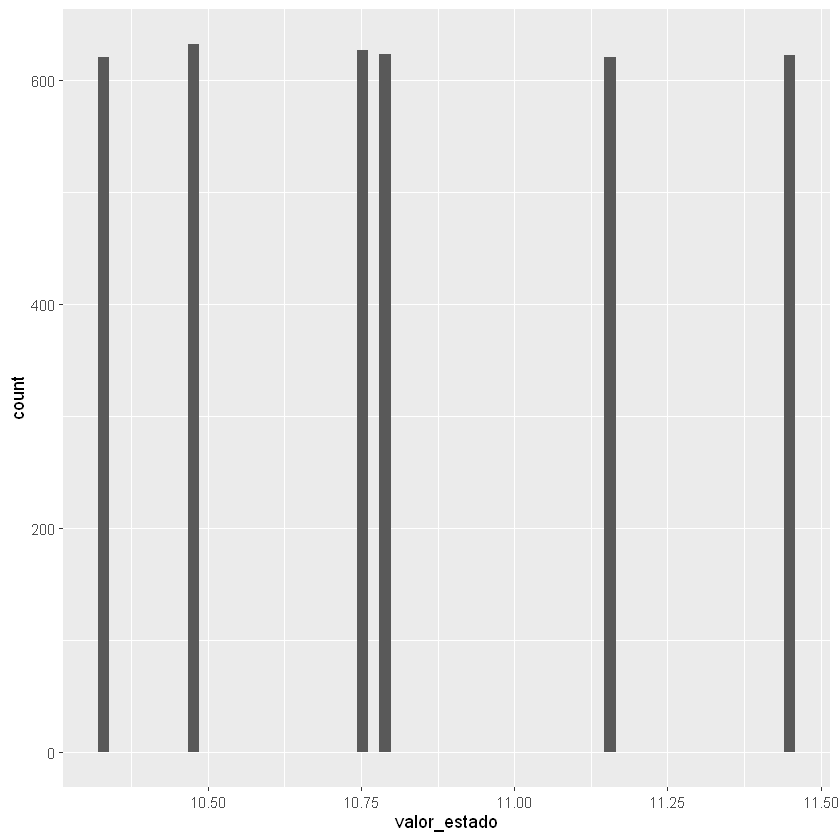

In [480]:
dados_plot <- data.frame(
  valor_estado = MEDIDAS_DESENV$longevidade_1$valor_estado
)

ggplot(
    dados_plot, 
    aes(x = valor_estado)) +
    geom_histogram(
        bins = get_raiz_quadrada(array_teste))

In [481]:
n = length((valores))
k = 1 + log2(n)

k_sturges <- nclass.Sturges(valores)

In [482]:
library(ggplot2)
library(dplyr)
library(purrr)
library(patchwork)

# 1. Função base para calcular a Moda 
calcular_moda <- function(v) {
  uniqv <- unique(v)
  uniqv[which.max(tabulate(match(v, uniqv)))]
}

# 2. O Motor de Análise e Plotagem
gerar_relatorio_indicador <- function(df, nome_metrica) {
  
  # --- ROTEAMENTO SEMÂNTICO (CORES E CATEGORIAS) ---
  if (grepl("longevidade", nome_metrica, ignore.case = TRUE)) {
    cat_label <- "Longevidade"
    cor_fill  <- "#e46a18"  # Laranja vibrante tipo Python
    cor_line  <- "#cc3a00"  # Borda levemente mais escura
  } else if (grepl("escolaridade", nome_metrica, ignore.case = TRUE)) {
    cat_label <- "Escolaridade"
    cor_fill  <- "#4682B4"  # Steel Blue
    cor_line  <- "#315B7E"
  } else if (grepl("economia|consumo", nome_metrica, ignore.case = TRUE)) {
    cat_label <- "Economia e Consumo"
    cor_fill  <- "#BA55D3"  # Roxo suave/Magenta (Medium Orchid)
    cor_line  <- "#520568"
  } else {
    cat_label <- "Geral"
    cor_fill  <- "#95A5A6"  # Cinza Neutro (Fallback de segurança)
    cor_line  <- "#7F8C8D"
  }
  
  # --- EXTRAÇÃO E CÁLCULOS ---
  vetor <- na.omit(df$valor_estado)
  df_plot <- data.frame(valor = vetor)
  
  media_val <- mean(vetor)
  mediana_val <- median(vetor)
  moda_val <- calcular_moda(vetor)
  var_val <- var(vetor)
  dp_val <- sd(vetor)
  
  bins_sturges <- nclass.Sturges(vetor)
  
  linha_estatistica <- data.frame(
    Metrica = toupper(nome_metrica),
    Categoria = cat_label,
    Media = round(media_val, 4),
    Moda = round(moda_val, 4),
    Mediana = round(mediana_val, 4),
    Variancia = round(var_val, 4),
    Desvio_Padrao = round(dp_val, 4)
  )
  
  # --- BLOCO VISUAL ---
  # A. Histograma Calibrado (Sturges)
  p_hist <- ggplot(df_plot, aes(x = valor)) +
    geom_histogram(bins = bins_sturges, fill = cor_fill, color = "white") +
    labs(title = "Histograma", subtitle = paste("K (Sturges) =", bins_sturges), x = "Valor", y = "Frequência") +
    theme_minimal()
  
  # B. Gráfico KDE (Densidade)
  p_kde <- ggplot(df_plot, aes(x = valor)) +
    geom_density(fill = cor_fill, alpha = 0.4, color = cor_line, linewidth = 1) +
    labs(title = "KDE", subtitle = "Densidade Empírica", x = "Valor", y = "Densidade") +
    theme_minimal()
  
  # C. Boxplot
  p_box <- ggplot(df_plot, aes(y = valor)) +
    geom_boxplot(fill = cor_fill, color = cor_line, width = 0.5, alpha = 0.8) +
    labs(title = "Boxplot", subtitle = "Dispersão/Outliers", y = "Valor") +
    theme_minimal() +
    theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())
  
  # Alinhamento com patchwork + Injeção da Legenda Superior Esquerda
  painel_grafico <- p_hist + p_kde + p_box + 
    plot_layout(ncol = 3) +
    plot_annotation(
      title = paste("RAIO-X DO INDICADOR:", toupper(nome_metrica)),
      subtitle = paste("CATEGORIA INDICADOR:", toupper(cat_label)),
      theme = theme(
        plot.title = element_text(face = "bold", size = 15, hjust = 0),
        plot.subtitle = element_text(color = cor_fill, face = "bold", size = 11, hjust = 0) # Cor acompanha a categoria
      )
    )
  
  return(list(Estatisticas = linha_estatistica, Grafico = painel_grafico))
}

# 3. Execução em Lote
resultados_analise <- imap(metricas_desenvolvimento, gerar_relatorio_indicador)

# ==============================================================================
# SAÍDAS PRONTAS PARA USO
# ==============================================================================

# 1. Visualizar Tabela
tabela_final <- map_dfr(resultados_analise, "Estatisticas")
print(tabela_final)

# 2. Testar o visual de cada categoria
# resultados_analise
Grafico     # Laranja Python
# resultados_analise
Grafico    # Steel Blue
# resultados_analise
Grafico        # Magenta

          Metrica          Categoria      Media     Moda   Mediana    Variancia
1   LONGEVIDADE_1        Longevidade    10.8240    10.47    10.760 1.464000e-01
2   LONGEVIDADE_2        Longevidade    12.4834    13.43    12.460 2.123000e-01
3   LONGEVIDADE_3        Longevidade     1.2500     1.32     1.280 7.600000e-03
4   LONGEVIDADE_4        Longevidade    15.8600    15.79    15.675 1.222400e+00
5  ESCOLARIDADE_1       Escolaridade    46.1804    38.50    47.190 1.866090e+01
6  ESCOLARIDADE_2       Escolaridade    59.2950    50.89    58.950 2.849060e+01
7  ESCOLARIDADE_3       Escolaridade    28.4967    20.17    30.095 2.286780e+01
8  ESCOLARIDADE_4       Escolaridade    12.2857    14.50    13.230 2.910000e+00
9      ECONOMIA_1 Economia e Consumo 79197.8667 90454.96 82664.825 7.630215e+07
10     ECONOMIA_2 Economia e Consumo  2177.6167  2343.84  2166.090 1.451101e+04
11      CONSUMO_1 Economia e Consumo     2.6400     2.69     2.670 2.590000e-02
12      CONSUMO_2 Economia e Consumo    

ERROR: Error: objeto 'Grafico' não encontrado


### **Testes com indicadores de Longevidade:**

In [ ]:
# 1. Criando uma "coluna" de dados de exemplo (1000 valores aleatórios)
coluna_dados <- metricas_desenvolvimento$longevidade_1$valor_estado

# 2. Calculando o número ideal de barras (K) usando a Regra de Sturges nativa do R
k_sturges <- nclass.Sturges(coluna_dados)

# 3. Desenhando o histograma simples
hist(coluna_dados, 
     breaks = k_sturges,                                     # Aplica a regra de Sturges
     col = "steelblue",                                      # Cor das barras
     border = "white",                                       # Cor da borda
     main = paste("Histograma - Regra de Sturges (K =", k_sturges, ")"), # Título
     xlab = "Valores da Coluna",                             # Eixo X
     ylab = "Frequência")                                    # Eixo Y

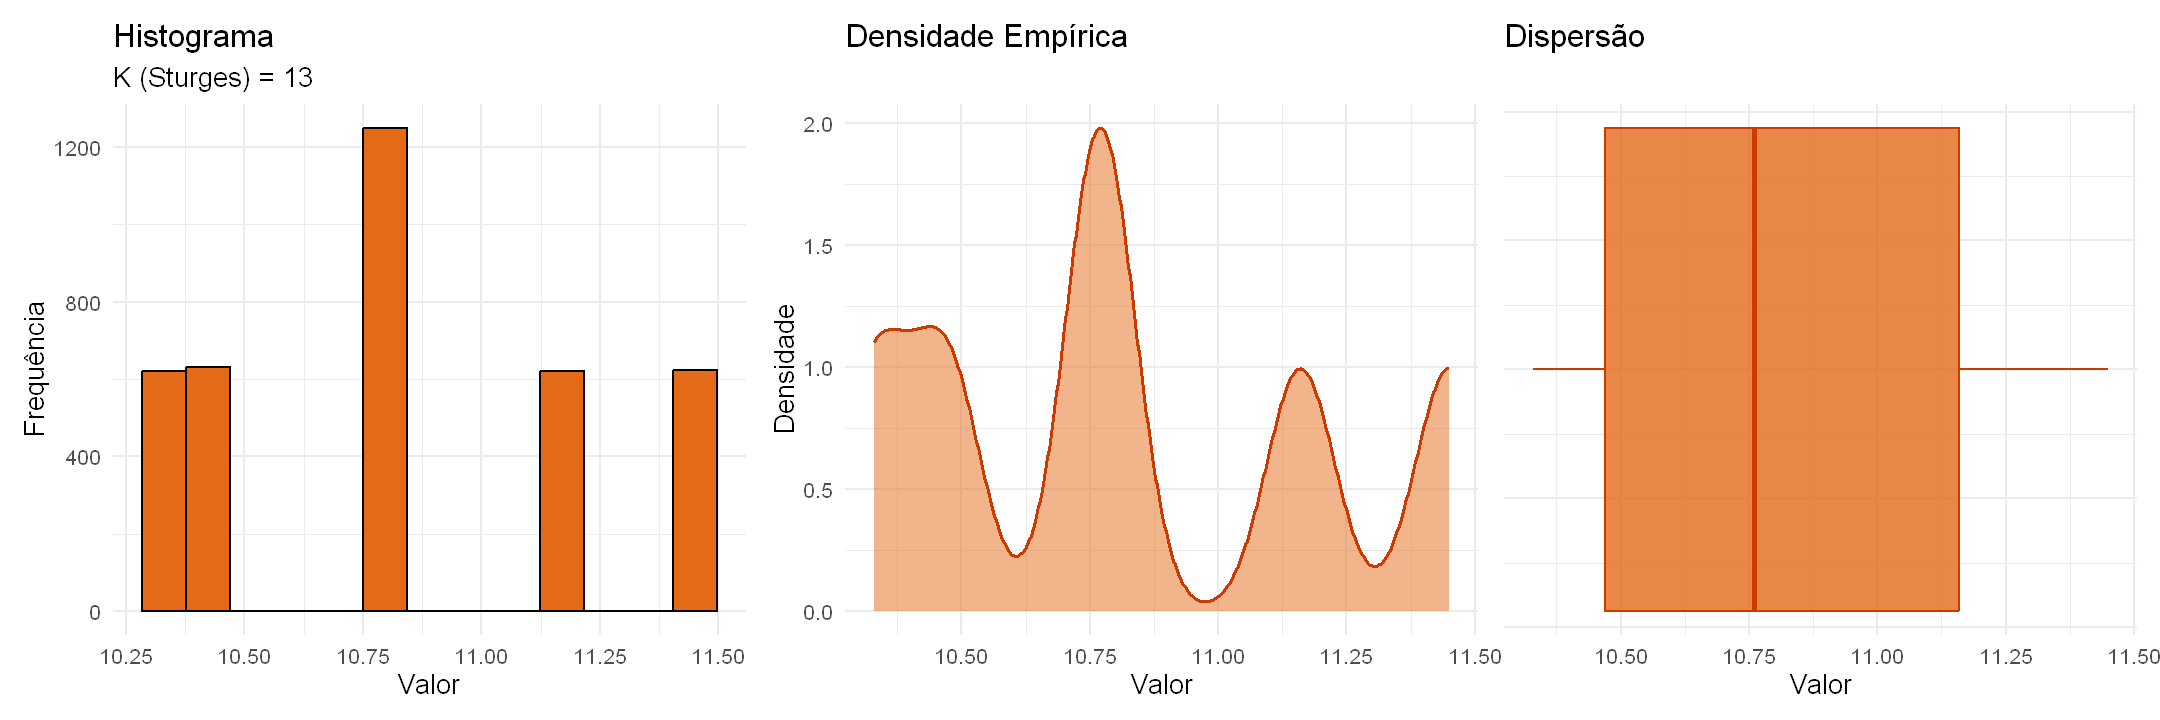

In [ ]:
# # 1. Trava o tamanho do gráfico para a célula do Jupyter Notebook (Largura x Altura em polegadas)
# # options(repr.plot.width = 18, repr.plot.height = 6)

# # 2. Pacotes
# library(ggplot2)
# library(patchwork)

# dados_exemplo <- data.frame(
#     valor_estado = metricas_desenvolvimento$longevidade_1$valor_estado)

# k_sturges <- nclass.Sturges(dados_exemplo$valor_estado)

# cor_fundo <- "#e46a18"  # Laranja
# cor_borda <- "#cc3a00"  # Laranja Escuro
# fonte_base <- 16          # Tamanho da fonte legível

# # 4. Gráficos Individuais
# # A. Histograma
# p_hist <- ggplot(dados_exemplo, aes(x = valor_estado)) +
#   geom_histogram(bins = k_sturges, fill = cor_fundo, color = "black") +
#   labs(title = "Histograma", subtitle = paste("K (Sturges) =", k_sturges), x = "Valor", y = "Frequência") +
#   theme_minimal(base_size = fonte_base)

# # B. Curva KDE
# p_kde <- ggplot(dados_exemplo, aes(x = valor_estado)) +
#   geom_density(fill = cor_fundo, alpha = 0.5, color = cor_borda, linewidth = 1) +
#   labs(title = "Densidade Empírica", x = "Valor", y = "Densidade") +
#   theme_minimal(base_size = fonte_base)

# # C. Boxplot (Eixo X para acompanhar a leitura dos outros gráficos)
# p_box <- ggplot(dados_exemplo, aes(x = valor_estado)) +
#   geom_boxplot(fill = cor_fundo, color = cor_borda, alpha = 0.8) +
#   labs(title = "Dispersão", x = "Valor") +
#   theme_minimal(base_size = fonte_base) +
#   theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())


# painel <- p_hist + p_kde + p_box
# painel

In [ ]:
install.packages('ggplot')
library(ggplot2)

ggplot(data = coluna_dados)

Instalando pacote em 'C:/Users/Ivan/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



Warning message:
"pacote 'ggplot' não está disponível for this version of R

Uma versão deste pacote para a sua versão do R pode estar disponível em outro lugar,
veja as ideias em
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


ERROR: Error: objeto 'coluna_dados' não encontrado


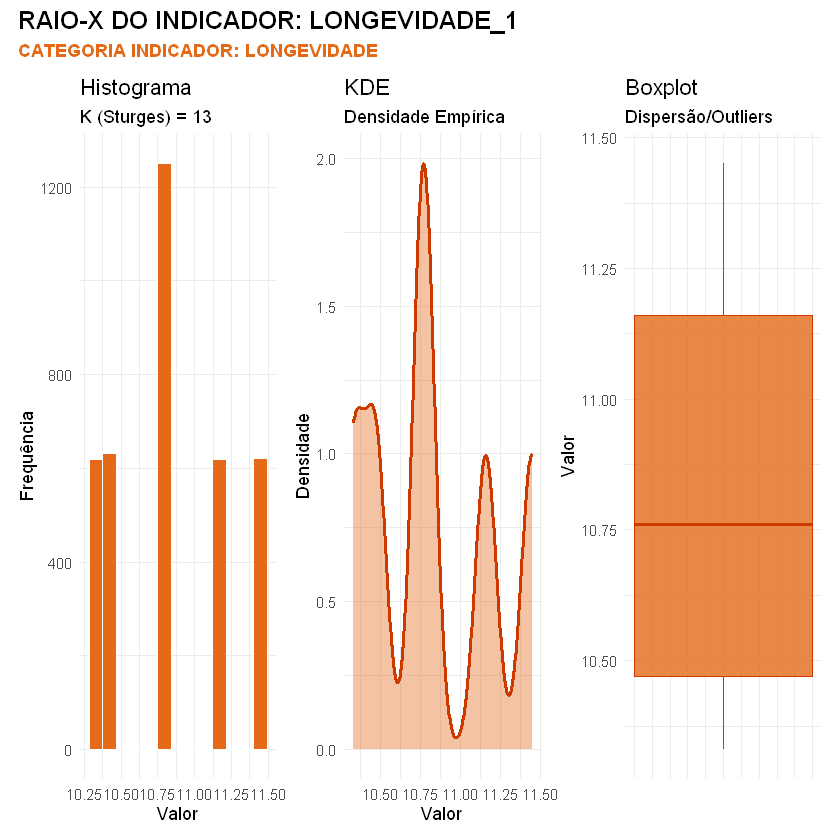

In [ ]:
resultados_analise$longevidade_1$Grafico     # Laranja Python

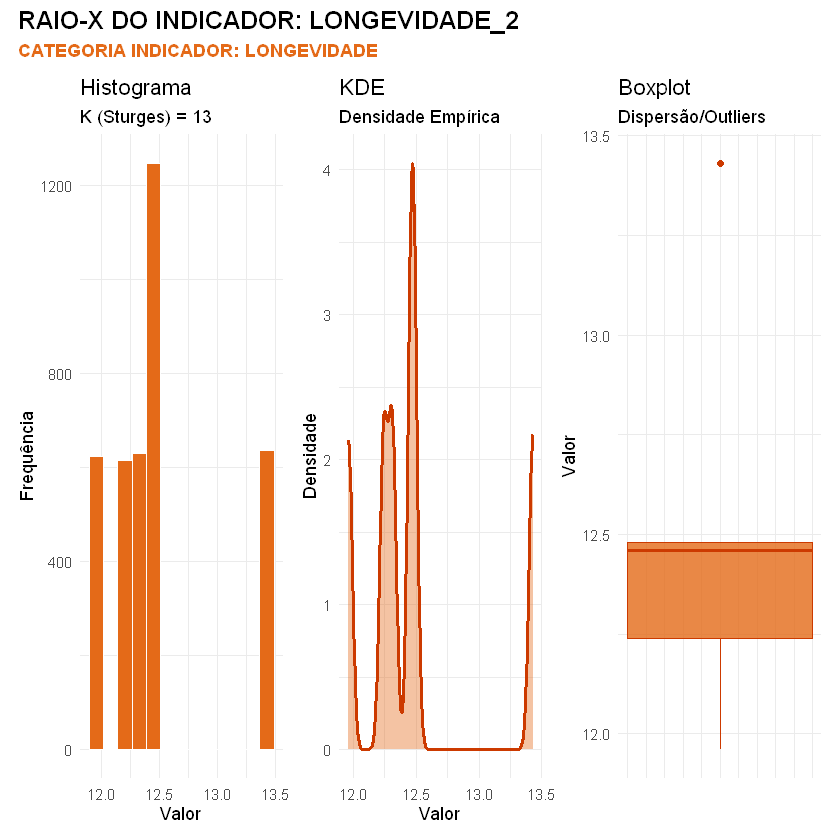

In [ ]:
resultados_analise$longevidade_2$Grafico

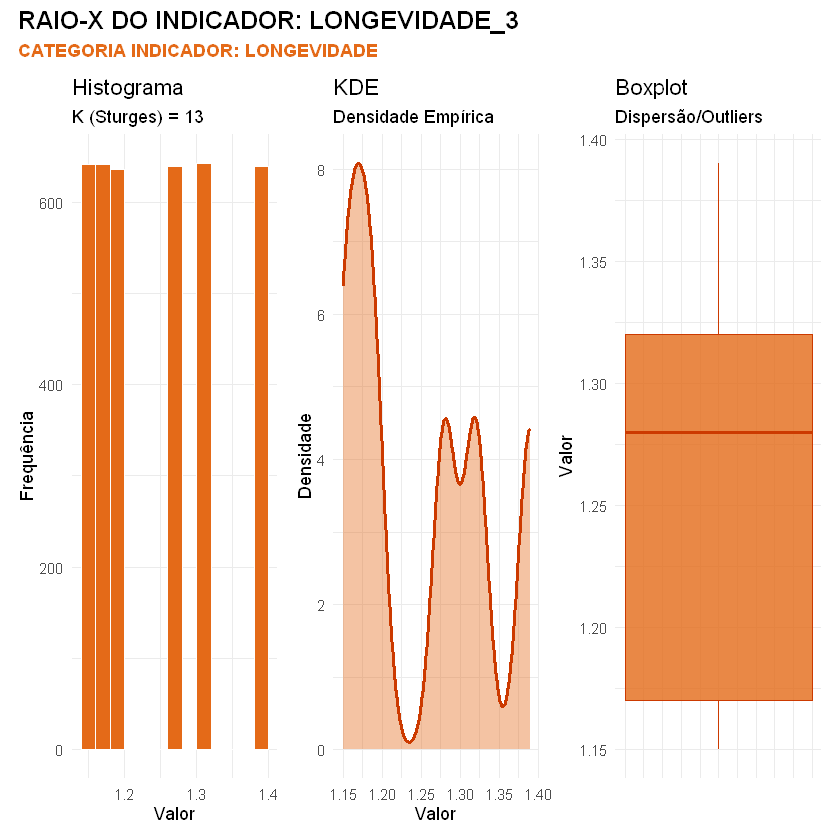

In [ ]:
resultados_analise$longevidade_3$Grafico

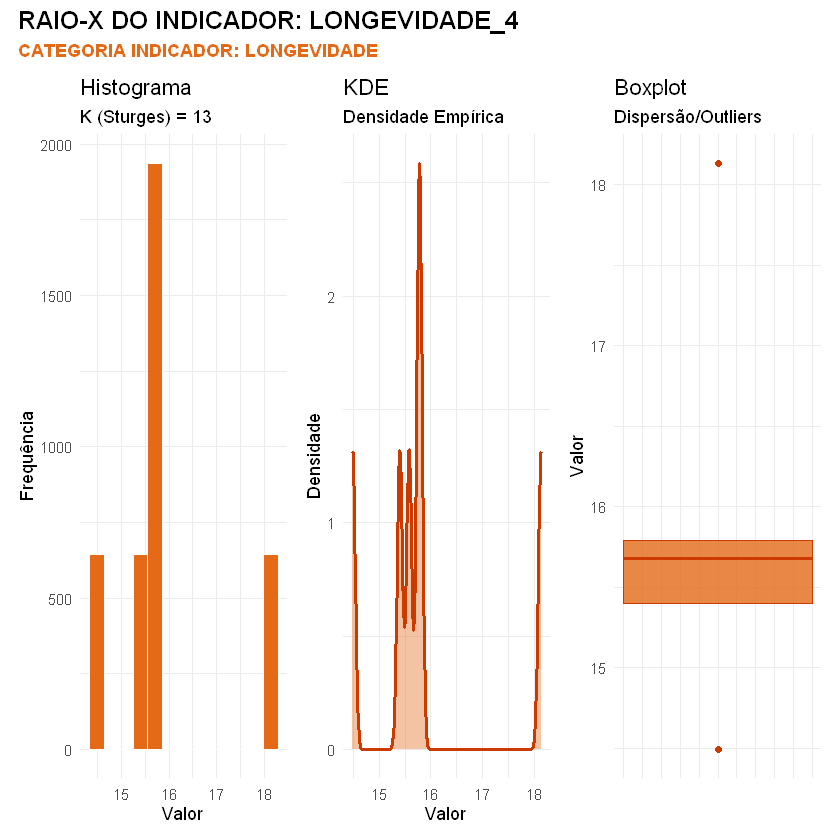

In [ ]:
resultados_analise$longevidade_4$Grafico

### **Testes com indicadores de Escolaridade:**

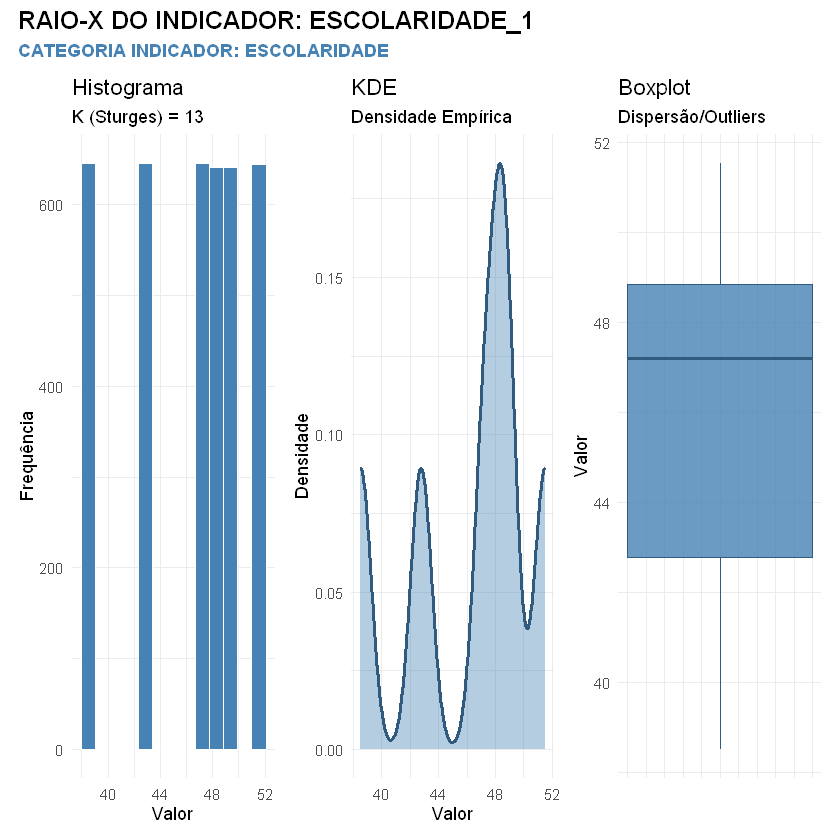

In [ ]:
resultados_analise$escolaridade_1$Grafico

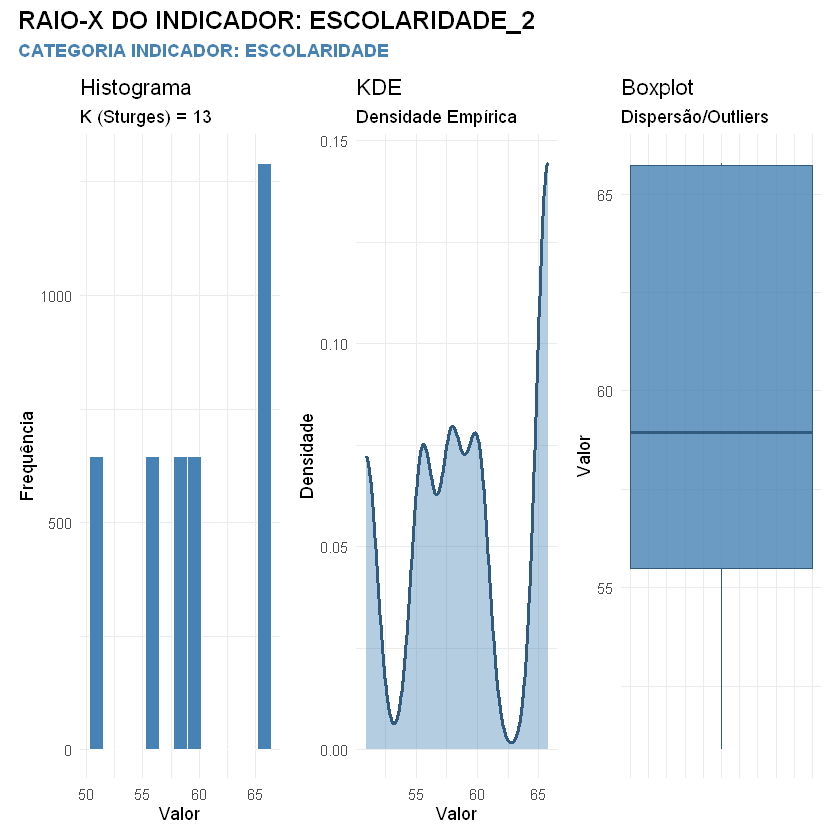

In [ ]:
resultados_analise$escolaridade_2$Grafico

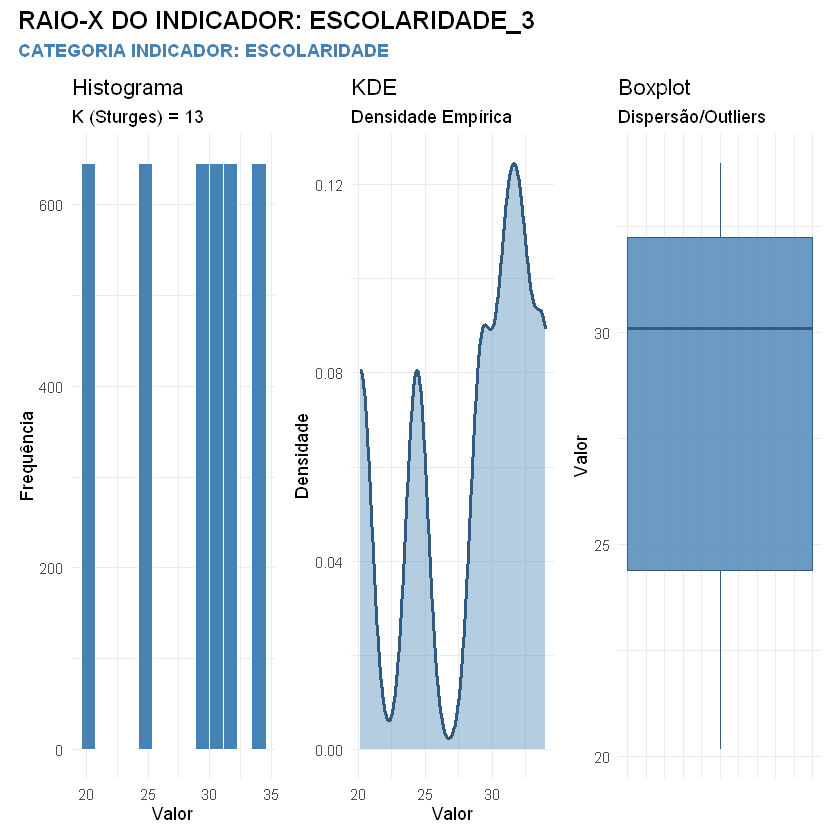

In [ ]:
resultados_analise$escolaridade_3$Grafico

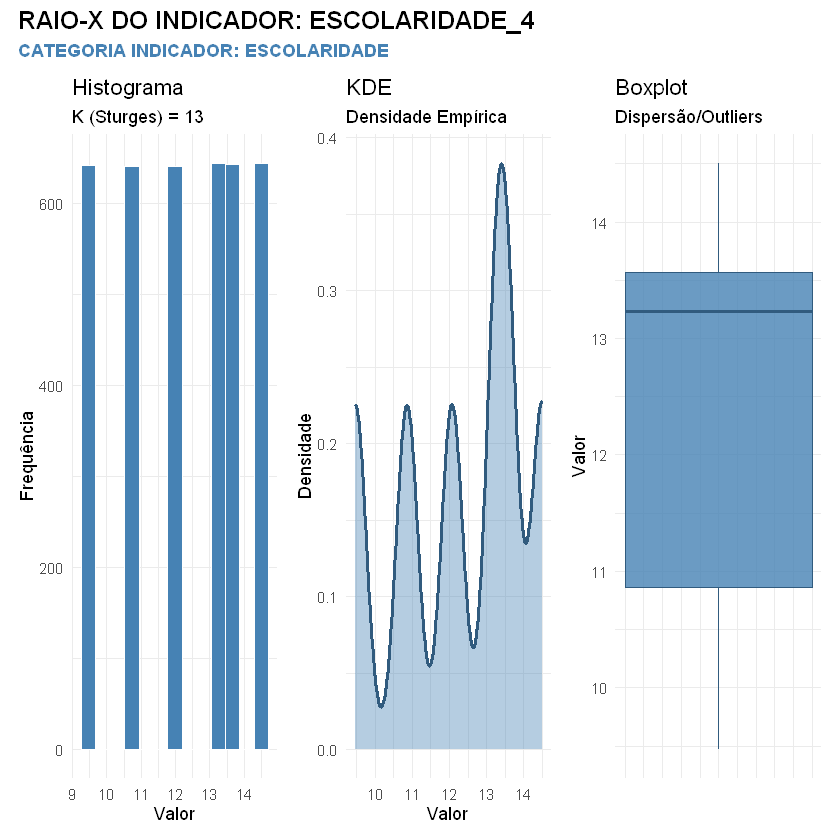

In [ ]:
resultados_analise$escolaridade_4$Grafico

### **Testes com indicadores sobre fatores da Economia & Consumo:**

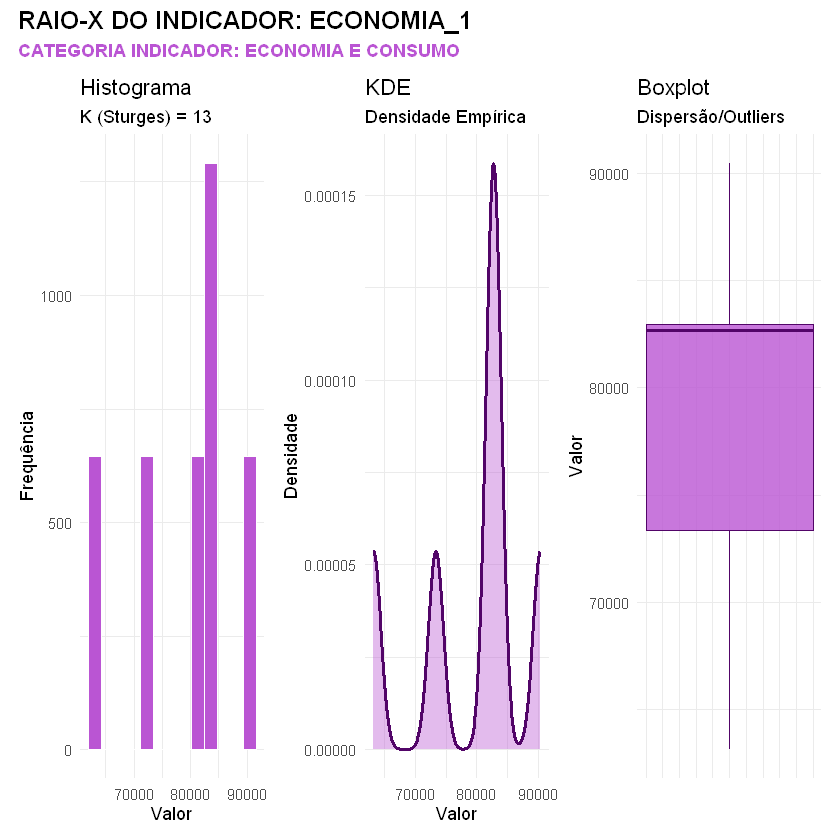

In [ ]:
resultados_analise$economia_1$Grafico

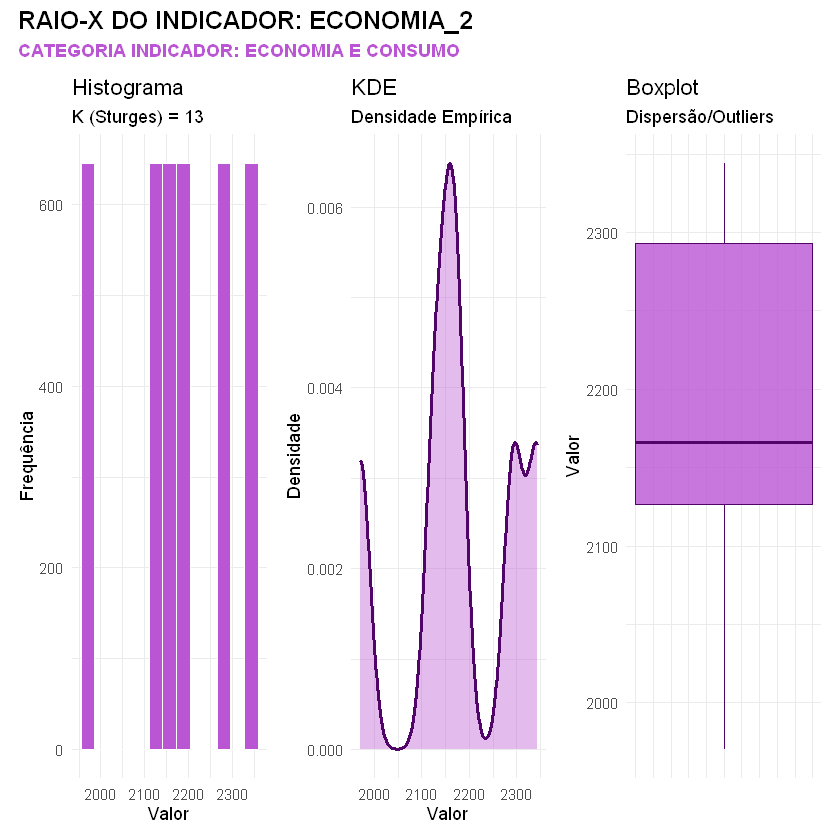

In [ ]:
resultados_analise$economia_2$Grafico

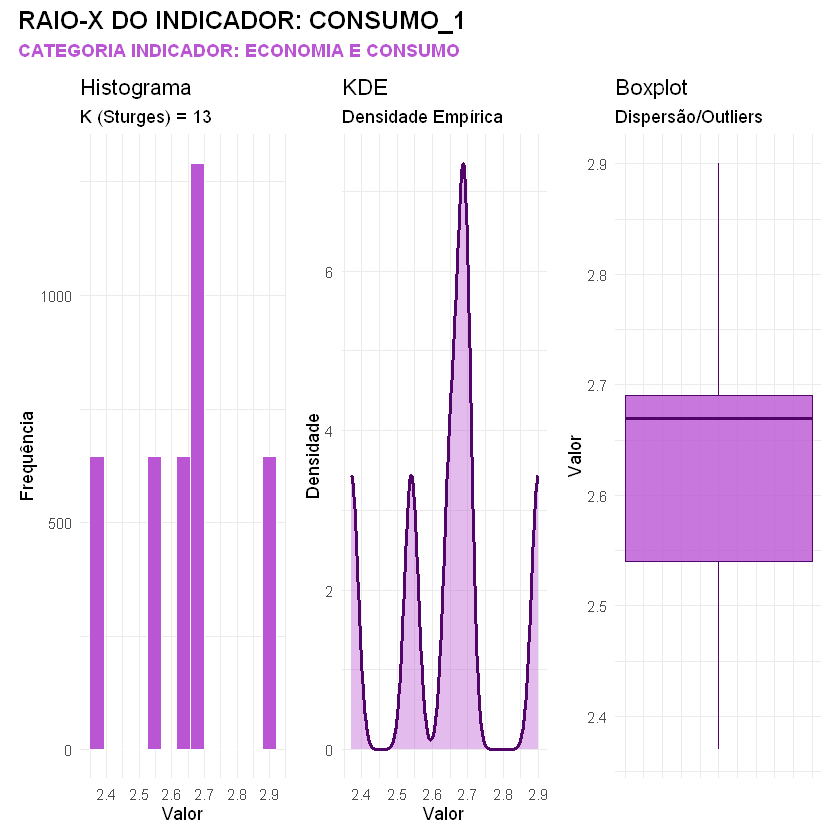

In [ ]:
resultados_analise$consumo_1$Grafico

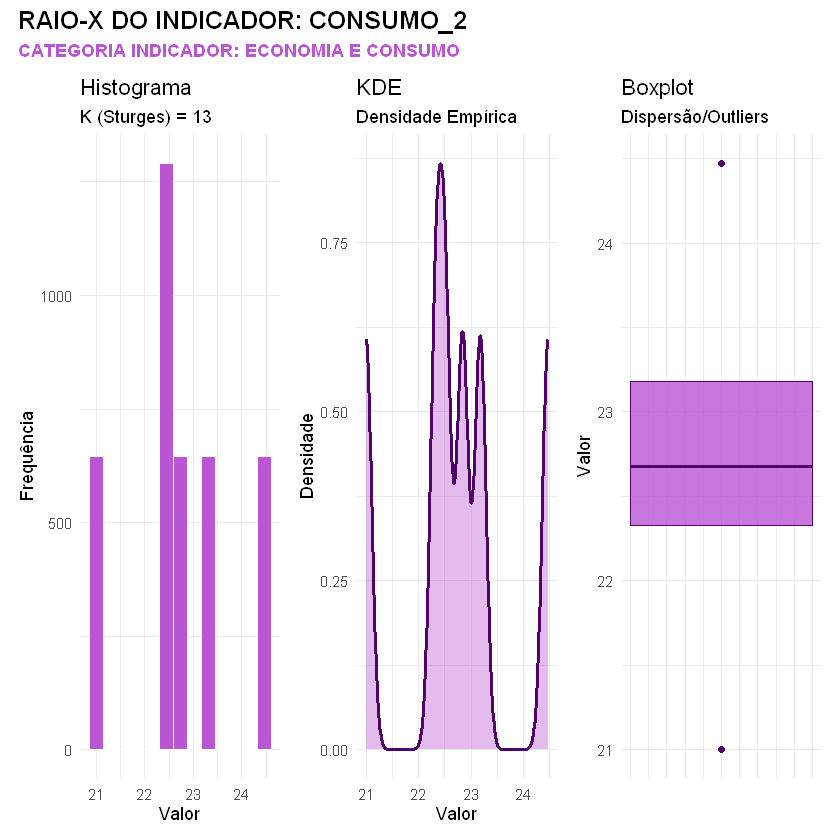

In [ ]:
resultados_analise$consumo_2$Grafico